# ML-bike: predicting city-bike trip duration from calendar and weather

**Goal:** predict how long a city-bike trip takes, given when it starts and what the weather is like.

**ML problem formulation**
- **Data point:** one bike trip.
- **Features:** weekday, hour of day, month, daily mean temperature, daily precipitation.
- **Label:** trip duration in minutes.
- **Hypothesis spaces:** linear models and gradient-boosted regression trees.
- **Loss:** Bike-share duration data has extreme outliers, e.g. a rider forgets to end the rental and the trip lasts all night. Those outliers' error are squared, so a handful of them can dominate the fit. 
We therefore compare squared error against two robust losses, Huber and absolute error (LAD), and select on mean absolute error.
- **Validation:** train on 2022–2023, validate on 2024, test on 2025.

**Data**
- `data/YYYY-MM.csv`: trips from the Helsinki & Espoo city-bike system, seasons April-October 2022-2025.
- `data/weather_daily.csv`: daily mean temperature and precipitation from the Finnish Meteorological Institute (FMI) open data (Helsinki Kaisaniemi station). 

Steps:
1. Setup
2. Load the trips
3. Load the weather
4. Merge and clean
5. Explore the outlier problem
6. What the features tell us
7. Features and train/validation/test split

## 1. Setup

In [1]:
import ssl
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
WEATHER_CSV = DATA_DIR / "weather_daily.csv"
RANDOM_STATE = 42

# Switch target to "distance_km" to predict distance instead. Everything below still works.
TARGET = "duration_min"

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Load the trips data

The monthly files all share the same columns. We need the departure time (for the calendar features and for joining weather by date), the duration (our label) and the distance (to filter out false starts, and as an alternative label).

In [2]:
COLUMNS = {
    "Departure": "departure",
    "Covered distance (m)": "distance_m",
    "Duration (sec.)": "duration_s",
}

files = sorted(p for p in DATA_DIR.glob("[0-9]*.csv"))
print(f"Found {len(files)} monthly trip files")

frames = []
for f in files:
    month_df = pd.read_csv(
        f,
        usecols=list(COLUMNS),
        dtype={"Covered distance (m)": "float32", "Duration (sec.)": "float32"},
    ).rename(columns=COLUMNS)
    frames.append(month_df)

trips = pd.concat(frames, ignore_index=True)
del frames

# Rows those hold only a date with no time of day become NaT and are dropped in step 4.
trips["departure"] = pd.to_datetime(trips["departure"], format="%Y-%m-%dT%H:%M:%S", errors="coerce")

print(f"Loaded {len(trips):,} trips")
trips.head()

Found 28 monthly trip files
Loaded 10,121,026 trips


,departure,distance_m,duration_s
0,2022-04-30 23:59:53,"1,204.00","128,982.00"
1,2022-04-30 23:59:39,559.00,284.00
2,2022-04-30 23:59:19,"2,199.00","1,078.00"
3,2022-04-30 23:59:03,"1,933.00",590.00
4,2022-04-30 23:58:55,"1,208.00",477.00


## 3. Load the weather data

`data/weather_daily.csv` holds daily observations from FMI's open data WFS API (Helsinki Kaisaniemi station, `fmisid=100971`):
- `tday` → `temp_c`, daily mean temperature in °C
- `rrday` → `precip_mm`, daily precipitation in mm

FMI reports **-1 mm** when no measurable precipitation fell, so we clip those to 0.

The cell below downloads the file if it is missing, so the notebook can be rerun from scratch. Hourly observations would match trips better, but a daily join is exactly the "minimal joining" this project needs, and rain on a given day is a reasonable proxy for cycling conditions.

In [3]:
FMISID = 100971  # Helsinki Kaisaniemi


def download_weather(path: Path, years=range(2022, 2026)) -> None:
    import certifi  # provides CA certificates; some Python installs cannot verify TLS without it

    context = ssl.create_default_context(cafile=certifi.where())
    ns = "{http://xml.fmi.fi/schema/wfs/2.0}"
    frames = []

    for year in years:
        query = urllib.parse.urlencode({
            "service": "WFS",
            "version": "2.0.0",
            "request": "getFeature",
            "storedquery_id": "fmi::observations::weather::daily::simple",
            "fmisid": FMISID,
            "starttime": f"{year}-04-01T00:00:00Z",
            "endtime": f"{year}-10-31T23:59:59Z",
            "parameters": "tday,rrday",
        })
        with urllib.request.urlopen(f"https://opendata.fmi.fi/wfs?{query}", timeout=120, context=context) as r:
            root = ET.fromstring(r.read())

        rows = [
            {
                "time": el.findtext(f"{ns}Time"),
                "name": el.findtext(f"{ns}ParameterName"),
                "value": pd.to_numeric(el.findtext(f"{ns}ParameterValue"), errors="coerce"),
            }
            for el in root.iter(f"{ns}BsWfsElement")
        ]
        wide = pd.DataFrame(rows).pivot_table(index="time", columns="name", values="value", aggfunc="first")
        wide.index = pd.to_datetime(wide.index).tz_convert(None).normalize()
        frames.append(wide)
        print(f"  downloaded {year}: {len(wide)} days")

    out = pd.concat(frames).sort_index().rename(columns={"tday": "temp_c", "rrday": "precip_mm"})
    out.index.name = "date"
    out[["temp_c", "precip_mm"]].to_csv(path, float_format="%.1f")


if not WEATHER_CSV.exists():
    print("Downloading weather from FMI open data...")
    download_weather(WEATHER_CSV)

weather = pd.read_csv(WEATHER_CSV, parse_dates=["date"]).set_index("date").sort_index()
weather["precip_mm"] = weather["precip_mm"].clip(lower=0)  # -1 means "no measurable rain"

print(f"{len(weather)} days, {weather.index.min().date()} -> {weather.index.max().date()}")
print(f"Rainy days (>= 0.1 mm): {(weather['precip_mm'] >= 0.1).mean():.1%}")
weather.describe()

856 days, 2022-04-01 -> 2025-10-31
Rainy days (>= 0.1 mm): 39.6%


,temp_c,precip_mm
count,856.00,856.00
mean,13.03,1.89
std,5.85,4.87
min,-2.00,0.00
25%,8.80,0.00
50%,13.75,0.00
75%,17.62,1.20
max,24.90,43.10


## 4. Merge and clean

We join weather onto trips by calendar date, then apply a minimal cleaning rule: drop missing values and false starts (under 10 seconds or under 10 metres, possibly when a bike is undocked and immediately re-docked).

We deliberately keep the long trips. Deleting them would be the easy way to make squared error behave, but it throws away real data and needs an arbitrary cut-off. Handling them with a robust loss is our choice here.

In [4]:
n_raw = len(trips)

trips = trips.dropna(subset=["departure", "duration_s", "distance_m"])
trips["date"] = trips["departure"].dt.normalize()
trips = trips.merge(weather, left_on="date", right_index=True, how="left")

no_weather = trips["temp_c"].isna()
print(f"Trips with no matching weather day: {no_weather.sum():,}")
trips = trips[~no_weather]

false_start = (trips["duration_s"] < 10) | (trips["distance_m"] < 10)
trips = trips[~false_start].reset_index(drop=True)

trips["duration_min"] = trips["duration_s"] / 60
trips["distance_km"] = trips["distance_m"] / 1000

print(f"Raw trips:        {n_raw:,}")
print(f"After cleaning:   {len(trips):,} ({len(trips) / n_raw:.1%})")
trips[["duration_min", "distance_km", "temp_c", "precip_mm"]].describe()

Trips with no matching weather day: 0
Raw trips:        10,121,026
After cleaning:   9,838,616 (97.2%)


,duration_min,distance_km,temp_c,precip_mm
count,"9,838,616.00","9,838,616.00","9,838,616.00","9,838,616.00"
mean,19.18,2.55,14.77,1.42
std,267.80,2.77,5.28,4.08
min,0.17,0.01,-2.00,0.00
25%,6.40,1.16,11.00,0.00
50%,10.85,1.99,15.70,0.00
75%,18.28,3.34,18.50,0.60
max,"279,454.31","3,681.01",24.90,43.10


## 5. Explore the outlier problem

In [ ]:
d = trips["duration_min"]
q = d.quantile([0.5, 0.9, 0.99, 0.999, 0.9999])

print(f"mean      {d.mean():8.1f} min")
print(f"median    {d.median():8.1f} min")
for level, value in q.items():
    print(f"p{level * 100:<8g} {value:8.1f} min")
print(f"max       {d.max():8.1f} min  ({d.max() / 60:.1f} hours)")
print()
print(f"Trips over 5 hours:  {(d > 300).sum():>8,}  ({(d > 300).mean():.3%} of trips)")
print(f"Trips over 24 hours: {(d > 1440).sum():>8,}  ({(d > 1440).mean():.4%} of trips)")

# How much of the total squared error around the mean comes from the tiny tail
sq_error = (d - d.mean()) ** 2
tail = d > 300
abs_error = (d - d.median()).abs()
print(f"\nTrips over 5 hours are {tail.mean():.3%} of the data, and they contribute:")
print(f"  {sq_error[tail].sum() / sq_error.sum():>6.1%} of the total squared error around the mean")
print(f"  {abs_error[tail].sum() / abs_error.sum():>6.1%} of the total absolute error around the median")

mean          19.2 min
median        10.9 min
p50           10.9 min
p90           27.6 min
p99           78.2 min
p99.9       1082.2 min
p99.99      5496.4 min
max       279454.3 min  (4657.6 hours)

Trips over 5 hours:    28,873  (0.293% of trips)
Trips over 24 hours:    5,553  (0.0564% of trips)

Trips over 5 hours are 0.293% of the data, and they contribute:
   99.7% of the total squared error around the mean
   36.0% of the total absolute error around the median


This printout is the argument for a robust loss. Under squared error, the ~0.3% of trips lasting over five hours account for almost all of the total error being minimised. Thus, a model fitted this way is, in effect, fitted to forgotten rentals. Under absolute error, the same trips carry roughly a third of the weight (much less, but still far more than their 0.3% share).

That second number is a useful warning. Absolute error is more robust, not immune, so MAE alone can still be swayed by the tail. This is why we also report the median absolute error, which describes the typical trip and is unaffected by how extreme the extremes are.

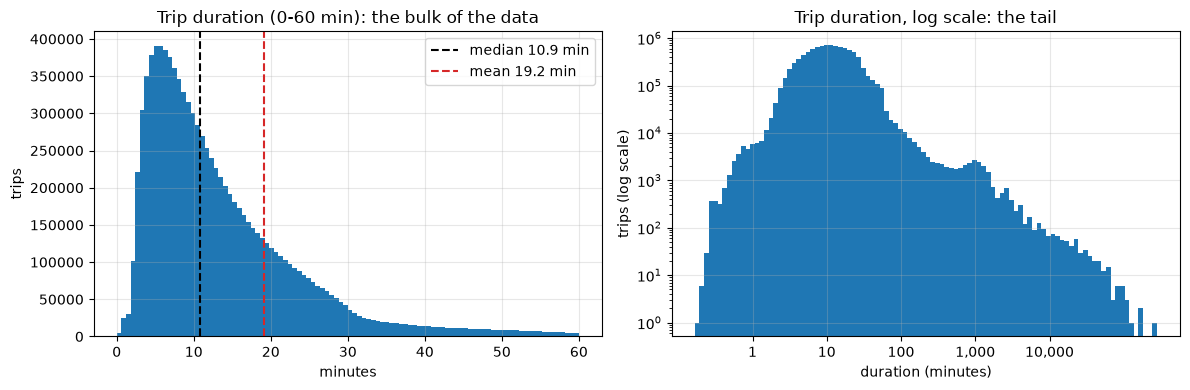

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(d, bins=100, range=(0, 60), color="tab:blue")
axes[0].axvline(d.median(), color="black", ls="--", label=f"median {d.median():.1f} min")
axes[0].axvline(d.mean(), color="tab:red", ls="--", label=f"mean {d.mean():.1f} min")
axes[0].set_title("Trip duration (0-60 min): the bulk of the data")
axes[0].set_xlabel("minutes")
axes[0].set_ylabel("trips")
axes[0].legend()

axes[1].hist(np.log10(d), bins=100, color="tab:blue")
axes[1].set_title("Trip duration, log scale: the tail")
axes[1].set_xlabel("duration (minutes)")
axes[1].set_xticks([0, 1, 2, 3, 4], ["1", "10", "100", "1,000", "10,000"])
axes[1].set_yscale("log")
axes[1].set_ylabel("trips (log scale)")

plt.tight_layout()
plt.show()

The mean sits clearly to the right of the median because the tail drags it. A model fitted with squared error predicts something close to a conditional mean, so it inherits that bias. A model fitted with absolute error predicts a conditional median, which describes a typical trip far better.

## 6. What the features tell us

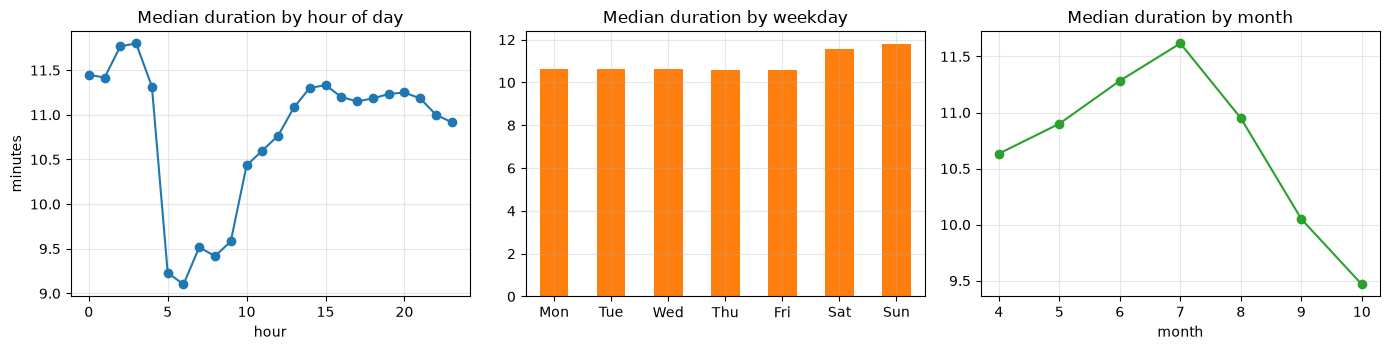

In [7]:
# Median is used throughout this section. It describes the typical trip and ignores the tail.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

trips.groupby(trips["departure"].dt.hour)["duration_min"].median().plot(ax=axes[0], marker="o")
axes[0].set_title("Median duration by hour of day")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("minutes")

by_weekday = trips.groupby(trips["departure"].dt.dayofweek)["duration_min"].median()
by_weekday.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday.plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set_title("Median duration by weekday")
axes[1].tick_params(axis="x", rotation=0)

trips.groupby(trips["departure"].dt.month)["duration_min"].median().plot(ax=axes[2], marker="o", color="tab:green")
axes[2].set_title("Median duration by month")
axes[2].set_xlabel("month")

plt.tight_layout()
plt.show()

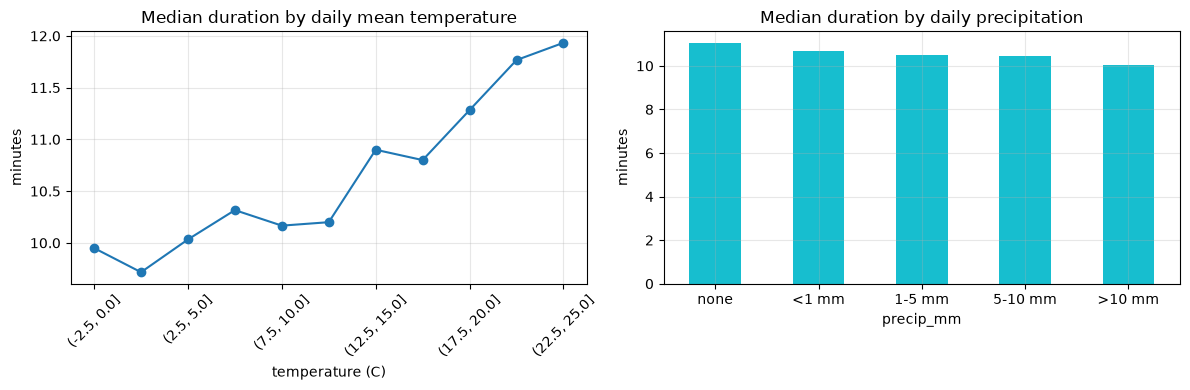

,median_duration,trips
precip_mm,,
none,11.03,6481829
<1 mm,10.67,1211079
1-5 mm,10.52,1368519
5-10 mm,10.43,350650
>10 mm,10.02,426539


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

temp_bins = pd.cut(trips["temp_c"], bins=np.arange(-5, 30, 2.5))
trips.groupby(temp_bins, observed=True)["duration_min"].median().plot(ax=axes[0], marker="o")
axes[0].set_title("Median duration by daily mean temperature")
axes[0].set_xlabel("temperature (C)")
axes[0].set_ylabel("minutes")
axes[0].tick_params(axis="x", rotation=45)

rain_bins = pd.cut(trips["precip_mm"], bins=[-0.01, 0.09, 1, 5, 10, 100],
                   labels=["none", "<1 mm", "1-5 mm", "5-10 mm", ">10 mm"])
stats = trips.groupby(rain_bins, observed=True).agg(
    median_duration=("duration_min", "median"), trips=("duration_min", "size")
)
stats["median_duration"].plot(kind="bar", ax=axes[1], color="tab:cyan")
axes[1].set_title("Median duration by daily precipitation")
axes[1].set_ylabel("minutes")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

stats

## 7. Features and train/validation/test split

The five features are exactly the ones the project calls for. Hour, weekday and month are categorical, so using one-hot encoding here lets the model fit each hour freely. Temperature and precipitation stay numeric.

The split is by season, because a random split of a time series leaks information between sets:

| Set | Seasons |
|---|---|
| Training | 2022, 2023 |
| Validation | 2024 |
| Test | 2025 |

Some models (Huber, LAD) are iterative and slow on millions of rows, so we fit on a fixed random sample of the training trips. Evaluation always uses every trip in the validation and test seasons.

In [9]:
CATEGORICAL = ["hour", "weekday", "month"]
NUMERIC = ["temp_c", "precip_mm"]
FEATURES = CATEGORICAL + NUMERIC
TRAIN_SAMPLE = 400_000


def make_features(df: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame(index=df.index)
    X["hour"] = df["departure"].dt.hour
    X["weekday"] = df["departure"].dt.dayofweek
    X["month"] = df["departure"].dt.month
    X["temp_c"] = df["temp_c"].astype("float64")
    X["precip_mm"] = df["precip_mm"].astype("float64")
    return X


X_all = make_features(trips)
y_all = trips[TARGET]
season = trips["departure"].dt.year

X_train_full, y_train_full = X_all[season <= 2023], y_all[season <= 2023]
X_val, y_val = X_all[season == 2024], y_all[season == 2024]
X_test, y_test = X_all[season == 2025], y_all[season == 2025]

sample = X_train_full.sample(TRAIN_SAMPLE, random_state=RANDOM_STATE).index
X_train, y_train = X_train_full.loc[sample], y_train_full.loc[sample]

for name, X in [("train (full)", X_train_full), ("train (sample)", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"{name:<16} {len(X):>10,} trips")
X_train.head()

train (full)      4,877,610 trips
train (sample)      400,000 trips
validation        2,508,945 trips
test              2,452,061 trips


,hour,weekday,month,temp_c,precip_mm
4611374,17,3,9,14.40,0.00
877330,16,3,6,15.20,0.00
953974,17,5,6,12.90,1.60
1909081,16,1,8,18.40,0.00
118978,14,0,4,7.90,0.00
